# Logistic Regression (Multi-class Classification)

## Approach 1: One vs Rest\All (OvA)
turn multi-class problem into *multiple binary classification problems*. \
for $K$ classes:
- train $k$ seperate models (works with any classifier model).
$$y = 
\begin{cases} 
1 & \text{if class $= k$} \\ 
0 & \text{otherwise} 
\end{cases}$$
- prediction
$$\text{compute: } P(y=k|x, \theta) \text{ for all } k$$
$$\text{then choose: } \hat{y} = \arg\max_kP(y=k|x,\theta)$$

## Approach 2: Multinomial Logistic Regression (Softmax)
directly model the multi-class problem using *a single model*. \
instead of splitting into binary tasks, we learn all classes *jointly*.

for $K$ classes:
- learn a parameter vector $\theta_k$ for each class
- compute probabilities using the softmax function
$$
P(y = k \mid x, \theta) = \frac{e^{\theta_k^T x}}{\sum_{j=1}^{K} e^{\theta_j^T x}}
$$

- prediction
$$\text{compute: } P(y=k|x, \theta) \text{ for all } k$$
$$\text{then choose: } \hat{y} = \arg\max_k P(y=k|x,\theta)$$

- training objective (cross-entropy loss)
$$
L(\theta) = -\sum_{k=1}^{K} \mathbf{1}(y = k)\log P(y=k \mid x, \theta)
$$

$$
L(\theta) = -\log\left(\frac{e^{\theta_k^T x}}{\sum_{j=1}^{K} e^{\theta_j^T x}}\right)
$$

$$
L(\theta) = - \left( \theta_y^\top x - \log \sum_{j=1}^{K} e^{\theta_j^\top x} \right)
$$

$$
L(\theta) = -\theta_y^\top x + \log \sum_{j=1}^{K} e^{\theta_j^\top x}
$$

- for a dataset of $N$ samples
$$
L(\theta) =
\sum_{i=1}^{N}
\left[
-\theta_{y^{(i)}}^\top x^{(i)} + \log \sum_{j=1}^{K} e^{\theta_j^\top x^{(i)}}
\right]
$$

### keys
- all class probabilities are computed *together*
- probabilities are normalized (sum to 1)
- classes compete directly with each other

### Common imports:

In [21]:
import numpy as np
import matplotlib.pyplot as plt

### Experimental datasets:

In [22]:
# suitable dataset for both approaches: OvA, multiomial
def make_data(n=100, ncls=3): # ncls: nclasses: max -> 5
    assert ncls < 6 and ncls > 0, "nclasses invalid"
    x, y = [], []
    ctrs = np.array([[0, 0], [3, 3], [-3, -3], [3, -3], [-3, 3]]) # centers
    for i in range(ncls):
        xi = ctrs[i] + np.random.randn(n//ncls, 2) # xi offsets from i's center
        yi = np.full(n//ncls, i)
        x.append(xi)
        y.append(yi)
    x = np.vstack(x)      # (n//ncls *ncls, 2) -> (n, 2)
    y = np.concatenate(y) # (n//ncls *ncls) -> (n)
    return x, y

In [23]:
N = 200
K = 5 # n classes

In [24]:
x, y = make_data(N, K)

In [25]:
x.shape

(200, 2)

In [26]:
y.shape

(200,)

In [27]:
def plot_data(x, y):
    plt.figure(figsize=(6,6))
    for cls in np.unique(y):
        plt.scatter(x[y==cls,0], x[y==cls,1], label=f'class {cls}')
    plt.title("Multi-class dataset")
    plt.xlabel("ft 1")
    plt.ylabel("ft 2")
    plt.legend()
    plt.grid(True)
    plt.show()

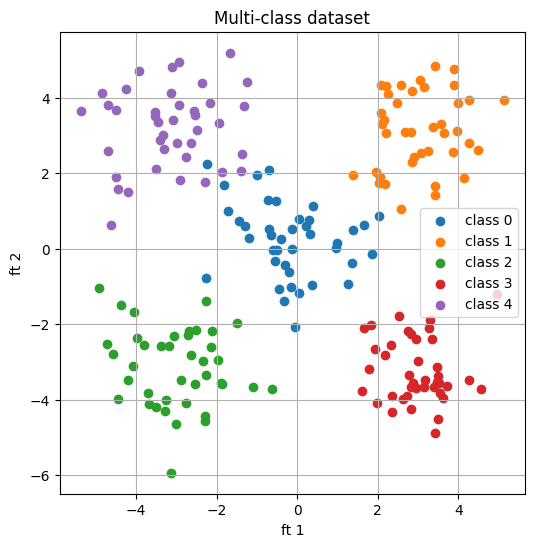

In [28]:
plot_data(x, y)

## OvA implemntation with logitstic regression

#### Model

In [53]:
def sig(z):
    z = np.clip(z, -500, 500)
    return 1/(1+np.exp(-z))

In [54]:
def forward(x, w, b):
    # x:(n,ncls) | w,b:(ncls,)
    z = x @ w + b # (n,)
    p = sig(z)
    return z, p

#### Loss

The binary cross-entropy formula:
$$
\mathcal{L}(w,b) = - \ell(w,b) 
                  = - \sum_{i=1}^{N} \Big[ y_i \log \sigma(z_i) + (1 - y_i) \log (1 - \sigma(z_i)) \Big]
$$
- if $z_i$ is very large positive, $\sigma(z_i)\approx1$, then $\log(1-\sigma(z_i))\approx\log(0)\rightarrow$ numerical underflow.
- if $z_i$ is very large positive, $\sigma(z_i)\approx0$, then $\log(\sigma(z_i))\approx\log(0)\rightarrow$ numerical underflow.

**Fix: compute loss using logits directly (stable cross-entropy)**
$$\mathcal{L}(w,b)=\sum_{i=1}^N\Big[\max(z_i, 0)-z_iy_i+\log(1+e^{-|z_i|})\Big]$$

In [31]:
# stable binary cross-entropy loss
## mean{ sum { y.log p + (1-y)log(1-p) } }
def cross_entropy(y, logits):
    # numerically stable bin-cross-ent.
    return np.mean(np.maximum(logits, 0)
                   - logits*y
                   + np.log1p(np.exp(-np.abs(logits)))) # log1p=log(1+x)

#### Gradients

We need:
$$\frac{\partial\mathcal{L}}{\partial w},\frac{\partial\mathcal{L}}{\partial b}=\frac{\partial\mathcal{L}}{\partial z}.\frac{\partial\mathcal{z}}{\partial w,b}$$

derivation:

$$\mathcal{L}_i=\max(z_i,0)-z_i y_i+\log(1+e^{-|z_i|})$$
$$\sigma(z)=\frac{1}{1+e^{-z}}$$
$$\quad \mathcal{L}=\frac{1}{N}\sum_{i=1}^N \mathcal{L}_i\Rightarrow \frac{\partial \mathcal{L}}{\partial z_i}=\frac{1}{N}(\sigma(z_i)-y_i)$$
$$\quad \nabla_w=\frac{1}{N}X^T(\sigma(z)-y)$$
$$\nabla_b=\frac{1}{N}\sum_{i=1}^N(\sigma(z_i)-y_i)$$

In [32]:
def grad(x, y, p):
    # x: (N,nin), y: (N,), preds: (N,) 
    dw = (1/x.shape[0])*(x.T @ (p-y)) # (nin,)
    db = np.mean(p-y) # scalar
    return dw, db

#### Training

In [57]:
def train(x, y, steps=300, lr=0.1):
    # x: (N. nin) | y: (nin)
    # theta: list of 2 dict. - theta[0]: weights, theta[1]: biases of k classes
    for s in range(steps):
        loss = []
        K = len(theta[0]) # n classes
        for k in range(K):
            yk = (y==k).astype(np.float32) # 1 if y==k, else 0

            # forward pass
            logits, p = forward(x, theta[0][k], theta[1][k])
            # loss
            loss.append(cross_entropy(yk, logits))
            # gradients
            dw, db = grad(x, yk, p)
            # gradient descent
            theta[0][k] -= lr*dw
            theta[1][k] -= lr*db

        if s%50==0:
            print(f"step: {s:4d} | avg loss: {np.mean(loss):.4f}")
    return theta, loss

In [58]:
## Instantiation
theta = [{}, {}]
theta[0] = {k:np.random.randn(x.shape[1])*0.1 for k in range(K)} # weights
theta[1] = {k:0.0 for k in range(K)}                             # biases

## Training the model
theta, loss = train(x, y, steps=500, lr=0.1)

step:    0 | avg loss: 0.6652
step:   50 | avg loss: 0.2975
step:  100 | avg loss: 0.2349
step:  150 | avg loss: 0.2065
step:  200 | avg loss: 0.1900
step:  250 | avg loss: 0.1791
step:  300 | avg loss: 0.1713
step:  350 | avg loss: 0.1654
step:  400 | avg loss: 0.1607
step:  450 | avg loss: 0.1570


#### Analysis

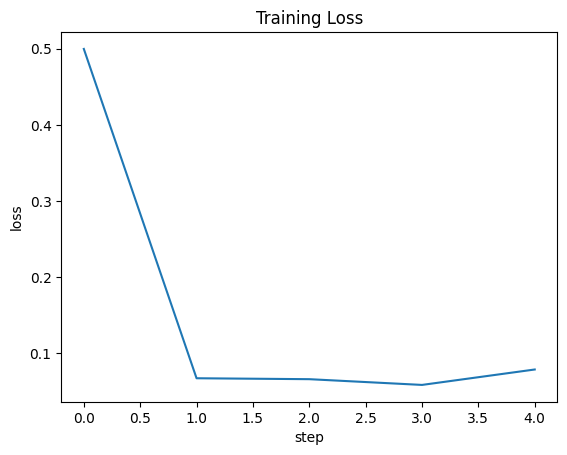

In [59]:
plt.plot(loss)
plt.title("Training Loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.show()

In [68]:
# final loss
loss[-1]

0.07858161305060044

In [76]:
# weights | class: weight1, weight2
theta[0]

{0: array([-0.01650183,  0.02628176]),
 1: array([1.13112283, 1.00331085]),
 2: array([-1.04143273, -1.09571771]),
 3: array([ 1.10545696, -1.03222181]),
 4: array([-0.97161319,  0.99345484])}

In [77]:
# biases | class: bias
theta[1]

{0: -1.3904951164761852,
 1: -3.322960509563455,
 2: -3.4171529445257103,
 3: -3.3957949149524427,
 4: -3.4245972542184875}

In [121]:
def predict(x, theta):
    k = len(theta[0])
    # probs: (N, K)
    probs = np.stack([forward(x, theta[0][k], theta[1][k])[1] for k in range(K)], axis=1) # stack probs
    return np.argmax(probs, axis=1)

In [122]:
# new datasets for testing
xte, yte = make_data(100, 5)

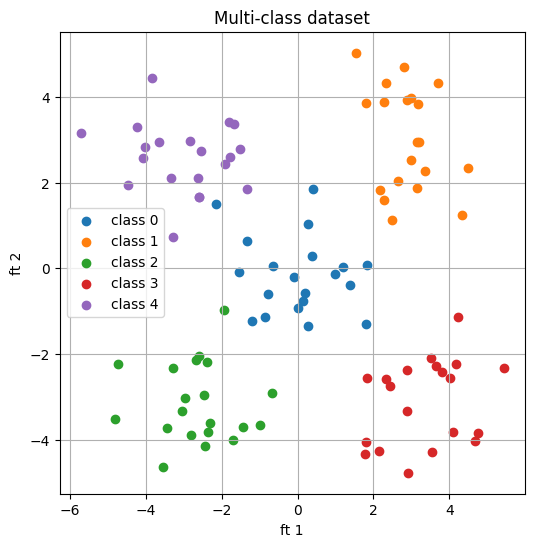

In [123]:
# visualise test data
plot_data(xte, yte)

In [128]:
# get predictions
ps = predict(xte, theta)

# calculate accuracy
acc = (ps==yte).mean()
print("Accuracy (test data): ", acc)

Accuracy (test data):  0.94
